[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)]([https://drive.google.com/file/d/1O30n5DlO5uFKk1gZj28qKh0sIcm0ghLg/view?usp=drive_link])

# TRANSFER LEARNING

Authors: Joseph Hellerstein & Valentina Staneva & Claude

This notebook is built on these sources:

* [*Tensorflow Classification Tutorial*](https://www.tensorflow.org/tutorials/images/classification)

* [*Transfer Learning with VGG16 and Keras*](https://towardsdatascience.com/transfer-learning-with-vgg16-and-keras-50ea161580b4),  Medium Blog Post by Gabriel Cassimiro

* [*Tensorflow Transfer Learning Tutorial*](https://www.tensorflow.org/tutorials/images/transfer_learning)

*  https://www.slideshare.net/xavigiro/transfer-learning-d2l4-insightdcu-machine-learning-workshop-2017

# Summary of Transfer Learning

Transfer learning is the practice of taking a model that was trained on one task and reusing it — fully or partially — as the starting point for a different task, rather than training from scratch.

### The Core Idea

When a CNN like VGG16 is trained on ImageNet, its convolutional layers learn general-purpose visual features that are useful far beyond ImageNet itself:

- **Early layers** learn low-level features: edges, corners, color gradients
- **Middle layers** learn mid-level features: textures, patterns, simple shapes
- **Later layers** learn high-level features: eyes, wheels, fur — things specific to the original task

These features turn out to be broadly useful for *any* image recognition task. Rather than relearning them from scratch, transfer learning lets you borrow them.
The term **base model** is used to refer to previously trained model that is reused with other tasks.


<img src="https://raw.githubusercontent.com/joseph-hellerstein/ai_in_practice/main/images/transfer_learning.png" width="750">

### Why It Works Well

- **Less data needed**: the conv base already knows how to see; you only need enough data to teach the new head your specific classes
- **Faster training**: you're only updating a small fraction of parameters
- **Better results**: especially when your dataset is small, starting from strong pretrained weights almost always outperforms training from scratch

### Transfer Learning & Software Engineering

Transfer learning promotes reuse, reproducibility, and resource efficiency.

# Setup

Import TensorFlow and other necessary libraries:

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pathlib
import tensorflow as tf
from sklearn.metrics.pairwise import cosine_similarity
from PIL import Image  # type: ignore
from tensorflow import keras # type: ignore
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.datasets import mnist # type: ignore
import tensorflow.keras.datasets as tfkds # type: ignore
import tensorflow_datasets as tfds # type: ignore
from tensorflow.keras.applications.vgg16 import VGG16 # type: ignore
from tensorflow.keras.callbacks import EarlyStopping # type: ignore
from tensorflow.keras import layers, models # type: ignore
from typing import List, Callable

In [2]:
os.environ["KERAS_BACKEND"] = "torch"
import keras
print(keras.backend.backend())

torch


In [3]:
# Constants
DATA_DIR = ""
IMAGE_PATH_DCT = {}

# Helpers

In [4]:
(X_TRAIN, Y_TRAIN), (X_TEST, Y_TEST) = keras.datasets.fashion_mnist.load_data()
# Manually define Fashion MNIST labels as tfds.load caused an AttributeError.
LABELS = np.array(['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'])

## plotAccuracy

In [5]:
def plotAccuracy(history, history_fine=None):
    """
    Plots accuracy over the history.
    """
    plt.rcParams["figure.figsize"] = [10, 5]
    plt.rcParams["figure.autolayout"] = True
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    epochs = range(1, len(history.history['accuracy']) + 1)

    if history_fine is not None:
        acc += history_fine.history['accuracy']
        val_acc += history_fine.history['val_accuracy']
        epochs = range(1, len(history.history['loss'])+ len(history_fine.history['accuracy'])+1)
    # Accuracy
    plt.plot(epochs, acc, label='Training Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy: Fine-tuned VGG')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1)

## plotLabelledImage

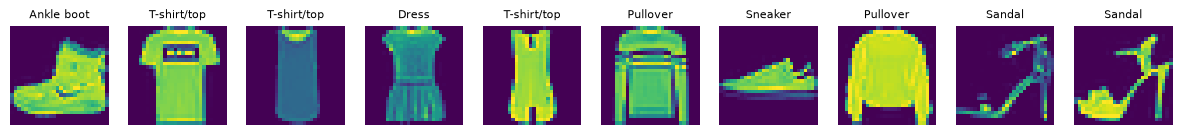

In [6]:
def plotLabelledImage(feature_arr: np.ndarray, label_arr: np.ndarray, num_image=10):
    feature_arr = feature_arr[0:num_image]
    label_arr = label_arr[0:num_image]
    # Plots images and labels
    num_fig = feature_arr.shape[0]
    _, axes = plt.subplots(1, num_fig, figsize=(15,15))
    for idx in range(num_fig):
        ax = axes[idx]  # type: ignore
        if feature_arr.ndim == 4:
            ax.imshow(feature_arr[idx, :, :, :].astype("uint8"))
        else:
            ax.imshow(feature_arr[idx, :, :].astype("uint8"))
        ax.axis('off')              # optional: hides the axis ticks
        text = label_arr[idx]
        if not isinstance(text, str):
            text = str(text[0])
        ax.set_title(text, fontsize=8)
    plt.show()

# TESTS
num_image = 10
plotLabelledImage(X_TRAIN, LABELS[Y_TRAIN], num_image=num_image)

## print_cosine_similarity, show_pair

In [7]:
def print_cosine_similarity(embedding_a, embedding_b):
  cos = cosine_similarity(embedding_a, embedding_b)
  # We do this to limit the number of decimals in the printed output
  result = f'Cosine similarity = {cos:.2f}'
  print(result)

def show_pair(imag_a, imag_b):
  plt.subplot(121)
  plt.imshow(np.array(imag_a))
  plt.axis("off")

  plt.subplot(122)
  plt.imshow(np.array(imag_b))
  plt.axis("off")

# Essentials from CNN for Flowers

## Data

Data: 3,700 photos of flowers categorized as

```
  daisy
  dandelion
  roses
  sunflowers
  tulips
```

In [8]:
# Arranged in directories by class data_dir/flower_photo_extraced/daisy, ...
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
DATA_DIR = tf.keras.utils.get_file('flower_photos.tar', origin=dataset_url, extract=True)
DATA_DIR = pathlib.Path(DATA_DIR).with_suffix('')
DATA_DIR = os.path.join(DATA_DIR, "flower_photos")
print(DATA_DIR)


/Users/jlheller/.keras/datasets/flower_photos_extracted/flower_photos


In [9]:
# Create training and test datasets
HEIGHT = 150
WIDTH = 150
train_ds, test_ds = tf.keras.utils.image_dataset_from_directory(
  DATA_DIR,
  validation_split=0.2,
  subset="both",
  labels="inferred",
  label_mode="categorical",
  seed=123,
  image_size=(HEIGHT, WIDTH),
)
# convert to numpy arrays
train_images, train_labels = zip(*list(train_ds.unbatch()))
train_images = np.array(train_images)
train_labels = np.array(train_labels)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Using 734 files for validation.


## CNN Model

We first build a model for classifying flowers to provide a foundation for transfer learning. Some specifics of the model:
* Convolutional layers to find image features
* Dropouts to create a more robust model (and avoid fitting to noise)
* Data augmentation to handle different orientations of pictures

In [10]:
data_augmentation = keras.Sequential(
  [
    layers.RandomFlip("horizontal", input_shape=train_images[0,:,:,:].shape),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)

/Users/jlheller/home/Technical/repos/ai_in_practice/aip/lib/python3.11/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Data augmentation provides a way to automatically extend the data by having the same image in different rotations.

In [11]:
num_classes = len(train_ds.class_names)
model = Sequential([
  data_augmentation,
  layers.Rescaling(1./255),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.4),

  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.4),

  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.4),

  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dropout(0.4),

  layers.Dense(num_classes, name="outputs", activation='softmax')
])

In [12]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [13]:
%%time
es = EarlyStopping(monitor='val_accuracy', mode='max', patience=5,  restore_best_weights=True)
epochs=1
history = model.fit(
    train_images,
    train_labels,
    validation_split=0.2,
    epochs=epochs,
    batch_size=32,
    callbacks=[es]
)

74/74 ━━━━━━━━━━━━━━━━━━━━ 15s 201ms/step - accuracy: 0.2572 - loss: 1.7671 - val_accuracy: 0.3095 - val_loss: 1.5478
CPU times: user 3.28 s, sys: 464 ms, total: 3.74 s
Wall time: 15.1 s


We observe that:
* training accuracy is ~.76
* validation accuracy is ~.73

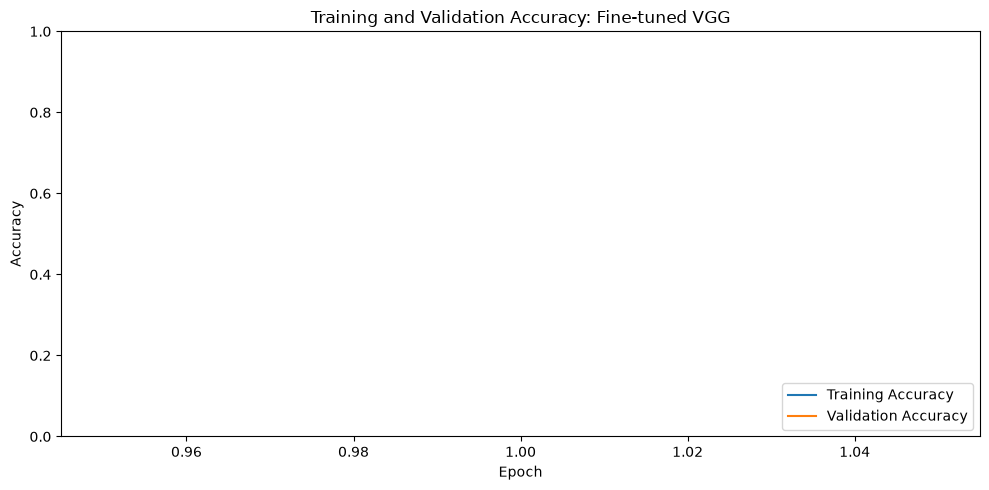

In [14]:
plotAccuracy(history)  # type: ignore

The training and validation behavior start to look more similar!

**Warning!** When doing data augmentation make sure augmented derivatives from the same image do not appear both in your train and validation datasets!

**Exercise:** Change some of the random transformation parameters and check if there is difference in performance.

**Exercise:** What other data augmentation techniques can be useful for this problem? Check if they are provided in [Keras](https://keras.io/api/layers/preprocessing_layers/image_augmentation/).

# Embeddings

<img src="https://raw.githubusercontent.com/joseph-hellerstein/ai_in_practice/main/images/embedding_models.png" width="500">

*https://learnopencv.com/embedding-models-explained/

### What is an embedding?

In [28]:
if DATA_DIR == "":
    DATA_DIR = "/Users/jlheller/.keras/datasets/flower_photos_extracted/flower_photos"
classes = ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
IMAGE_PATH_DCT = {}
for cls in classes:
    class_path = os.path.join(DATA_DIR, cls)  # type: ignore
    IMAGE_PATH_DCT[cls] = [os.path.join(class_path, f) for f in os.listdir(class_path)]

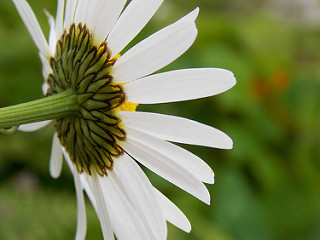

In [16]:
Image.open(IMAGE_PATH_DCT['daisy'][0])

In [29]:
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input  # type: ignore
from tensorflow.keras.preprocessing.image import img_to_array  # type: ignore

# Load the pretrained model (embeddings only, no top classification layer)
model = ResNet50(weights="imagenet", include_top=False, pooling="avg")

# Function to extract embeddings from an image
def extract_embedding(image_path):
    image = Image.open(image_path).convert("RGB")
    image = image.resize((224, 224))  # Keras models expect a fixed input size
    image_array = img_to_array(image)
    image_array = np.expand_dims(image_array, axis=0)  # Add batch dimension
    image_array = preprocess_input(image_array)  # Applies ImageNet normalization
    embedding = model.predict(image_array, verbose=0)
    return embedding.squeeze()

# Example usage
embedding = extract_embedding(IMAGE_PATH_DCT['daisy'][0])
print(embedding.shape)
print("\n\nFirst 10 elements of the embedding vector:")
embedding[:10]

(2048,)


First 10 elements of the embedding vector:


array([3.5319302 , 0.12086089, 0.41442677, 0.15401031, 0.22477637,
       0.6421027 , 0.52231425, 0.0102356 , 0.13792022, 0.01764445],
      dtype=float32)

## Cosine similarity

We compare objects by the closeness of their vector representations.
The **cosine similarity metric** is computed as the cosine of the angle between these two vectors.

$$ \text{Cosine Similarity} = \frac{A \cdot B}{\|A\| \|B\|} = \frac{\sum_{i=1}^{n} A_i B_i}{\sqrt{\sum_{i=1}^{n} A_i^2} \sqrt{\sum_{i=1}^{n} B_i^2}} $$



where:
- $ A $ and $ B $ are the feature vectors of the two images.
- $ A \cdot B $ is the dot product of vectors $ A $ and $ B $.
- $ \|A\| $ and $ \|B\| $ are the magnitudes (or norms) of vectors $ A $ and $ B $.

The result is a value between -1 and 1 that we can interpret easily:
- **1 indicates the vectors are identical:** 0 degree angle between the vectors, like a pair of vectors comprised of `vector_a = [1, 1, 1]`, `vector_b = [1, 1, 1]`.
- **0 indicates orthogonality: no similarity**, 90 degree angle between the vectors, the most extreme case of dissimilarity, like a pair of vectors comprised of `vector_a = [1, 1, 1]`, `vector_b = [0, 0, 0]`  .
- **-1 indicates signed opposite vectors:** 180 degree angle between the vectors, like a pair of vectors comprised of `vector_a = [5, 5, 5]`, `vector_b = [-5, -5, -5]`.

![](https://github.com/andandandand/image-dataset-curation/blob/main/images/orthogonal.png?raw=true)


Notice that the cosine similarity will output values between 0 and 1 when the input vectors are positive. This is how we most commonly use it to compare embeddings. It's advantageous that it's bounded between these two values for similar and  It's also important to know that there are many other ways that we can use to compute distance between vectors, with the [Euclidean distance](https://en.wikipedia.org/wiki/Euclidean_distance) being an alternative. The cosine similarity is strongly preferred over the Euclidean distance on many information-retrieval tasks as it is indifferent to the magnitude of the embedding vectors.

## Exploring cosine similarity

In [30]:
IMAGE_PATH_DCT.keys()

dict_keys(['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips'])

Cosine similarity = 0.35


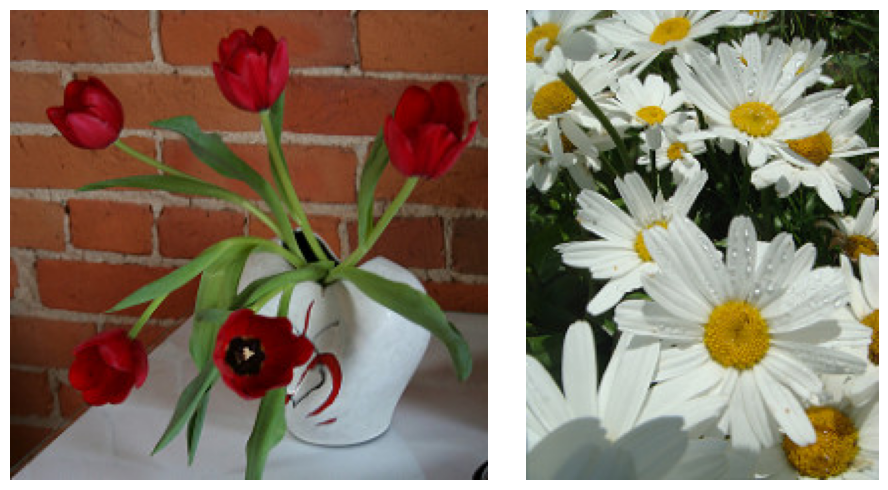

In [37]:
def get_random_image_from_class(cls):
    idx = np.random.randint(0, len(IMAGE_PATH_DCT[cls]))
    image_path = IMAGE_PATH_DCT[cls][idx]
    return image_path, extract_embedding(image_path)
def print_cosine_similarity(embedding_a, embedding_b):
    embedding_ap = embedding_a.reshape(1, -1)
    embedding_bp = embedding_b.reshape(1, -1)
    cos = cosine_similarity(embedding_ap, embedding_bp)[0, 0]
    result = f'Cosine similarity = {cos:.2f}'
    print(result)
##
a_image_path, a_embedding = get_random_image_from_class('tulips')
b_image_path, b_embedding = get_random_image_from_class('daisy')
print_cosine_similarity(a_embedding, b_embedding)
show_pair(Image.open(a_image_path), Image.open(b_image_path))

Explore cosine similarity by changing the class of flowers compared.

# Imagenet Model (VGG16)

VGG16 is a classic deep convolutional neural network developed by the Visual Geometry Group at Oxford University in 2014, and published in the paper *"Very Deep Convolutional Networks for Large-Scale Image Recognition"* by Simonyan and Zisserma. It was a top performer in the ImageNet Large Scale Visual Recognition Challenge (ILSVRC) 2014.

### Design Philosophy

The key insight of VGG16 was simplicity and depth: instead of using large kernels (like the 11×11 and 5×5 filters in earlier AlexNet), it stacks many small **3×3 Conv2D layers** with `padding='same'`, which:
- Keeps the architecture uniform and easy to reason about
- Uses fewer parameters than larger kernels while achieving the same receptive field
- Adds more non-linearity (more ReLU activations) which increases expressive power

The "16" in VGG16 refers to the 16 layers that have trainable parameters (13 conv + 3 dense).

<img src="https://raw.githubusercontent.com/joseph-hellerstein/ai_in_practice/main/images/vgg16.png" width="750">

### Architecture

| Block | Layers | Output Shape |
|---|---|---|
| Input | — | `(224, 224, 3)` |
| Block 1 | Conv2D(64) × 2, MaxPool | `(112, 112, 64)` |
| Block 2 | Conv2D(128) × 2, MaxPool | `(56, 56, 128)` |
| Block 3 | Conv2D(256) × 3, MaxPool | `(28, 28, 256)` |
| Block 4 | Conv2D(512) × 3, MaxPool | `(14, 14, 512)` |
| Block 5 | Conv2D(512) × 3, MaxPool | `(7, 7, 512)` |
| — | Flatten | `(25088,)` |
| — | Dense(4096), ReLU | `(4096,)` |
| — | Dense(4096), ReLU | `(4096,)` |
| — | Dense(1000), Softmax | `(1000,)` |

All Conv2D layers use `kernel_size=3`, `padding='same'`, and `activation='relu'`. All MaxPooling layers use `pool_size=(2,2)`, which is why spatial dims halve at each block. The final Dense(1000) corresponds to the 1000 ImageNet classes.

### Parameter Count

VGG16 has approximately **138 million parameters**, which was large even by 2014 standards. The striking thing is how lopsided the distribution is:

| Section | Params | % of total |
|---|---|---|
| All 13 Conv2D layers | ~15M | ~11% |
| Dense(4096) × 2 + Dense(1000) | ~123M | ~89% |

The two Dense(4096) layers alone account for the vast majority of parameters, which is why modern architectures (ResNet, EfficientNet, etc.) tend to use Global Average Pooling before the classifier head instead of Flatten → Dense, dramatically cutting parameter counts.

### Loading VGG16 in Keras

Keras includes VGG16 as a built-in model, optionally with ImageNet pretrained weights:

```python

model = VGG16(
    weights='imagenet',   # or None for random init
    include_top=True,     # False drops the Dense layers, useful for transfer learning
    input_shape=(224, 224, 3)
)

model.summary()
```

### Strengths and Weaknesses

| Strengths | Weaknesses |
|---|---|
| Simple, uniform architecture — easy to understand | 138M params — very heavy to train and store |
| Strong pretrained features, great for transfer learning | Slow inference compared to modern nets |
| Influenced almost all subsequent CNN designs | No skip connections — deep gradient flow can be difficult |
| Well studied and documented | Largely superseded by ResNet, EfficientNet, etc. |

Despite its age, VGG16 remains widely used as a **feature extractor** in transfer learning, since its convolutional blocks produce rich, general-purpose image features that transfer well to new tasks.

# Transfer Learning Using VGG16

Convolutional Neural Networks can be good feature extractors, i.e. a model trained on one dataset can turn out to be good at extracting useful features from another dataset. This allows deep learning methods to leverage large training sets and be able to generalize to situations where training data can be scarce.

* predict with a pretrained model on new data (zero-shot learning)
* extract features with a pretrained model and use them to train a shallow classifier on new data
* fine-tune the trained model to the new data by training with a small learning rate
* retrain the full model using the pre-trained model weights as initializers

As usual, we will have to evaluate the performance!

![TransferLearning](https://drive.google.com/uc?export=view&id=1QF9-eDrTkMouYJdU4k1qCklT3pLCI61u)

image src = https://www.slideshare.net/xavigiro/transfer-learning-d2l4-insightdcu-machine-learning-workshop-2017

<img src="https://i.stack.imgur.com/RTKux.png" width="750">

## Basic procedure

1. Load and initialize a pretrained model
    a. removing the top layer
    b. freeze the weights of the pretrained model
2. Shape the data for the pretrained model
3. Build the new model
    a. Add a new top layer appropriate for the data and task
4. Train the model
5. Evaluate the model

### 1. Load and initialize a pretrained model

In [20]:
# Load the model without the top layer
pretrained_model = VGG16(weights="imagenet", include_top=False, input_shape=(HEIGHT, WIDTH, 3))
# Freeze the model weights
pretrained_model.trainable = False ## Not trainable weights

In [21]:
pretrained_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

### 2. Shape the data for the base model

Pretrained models have certain expectations of how the data should look like so that it can be used in the model. They have a corresponding [`preprocess_input`](https://www.tensorflow.org/api_docs/python/tf/keras/applications/vgg16/preprocess_input) model. Make sure you read on the operations in the preprocessing so that it makes sense for your data.

In [22]:
from tensorflow.keras.applications.vgg16 import preprocess_input
preprocess_input(train_images.copy()).shape

(2936, 150, 150, 3)

**Warning!** The `preprocess_input` function changes the input **in-place** hence we need to pass a copy of the images.  

### 3. Build the new model

In [23]:
flatten_layer = layers.Flatten()
dense_layer_1 = layers.Dense(128, activation='relu')
prediction_layer = layers.Dense(5, activation='softmax')


model = models.Sequential([
    pretrained_model,
    flatten_layer,
    dense_layer_1,
    prediction_layer
])

In [24]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,764,037 (60.14 MB)

 Trainable params: 1,049,349 (4.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Notes
* ``flatten_1`` is dimensioned so that $ 8192 = 4 \times 4 \times 512$
* ``dense_2`` corresponds to our 5 classes

### 4. Train the new model

We train the model only for the new layers that we added.

In [25]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

In [26]:
%%time
es = EarlyStopping(monitor='val_accuracy', mode='max', patience=5,  restore_best_weights=True)
epochs=50
history = model.fit(
  preprocess_input(train_images.copy()),
  train_labels,
  validation_split=0.2,
  epochs=epochs,
  batch_size=32,
  callbacks=[es]
)

Epoch 1/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 9s 125ms/step - accuracy: 0.6342 - loss: 5.0445 - val_accuracy: 0.7449 - val_loss: 3.6167
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 9s 124ms/step - accuracy: 0.7994 - loss: 2.7046 - val_accuracy: 0.7602 - val_loss: 3.3833
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 9s 125ms/step - accuracy: 0.8428 - loss: 2.1530 - val_accuracy: 0.7670 - val_loss: 3.1863
Epoch 4/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 9s 124ms/step - accuracy: 0.8620 - loss: 1.9654 - val_accuracy: 0.7891 - val_loss: 2.9479
Epoch 5/50
 8/74 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - accuracy: 0.9012 - loss: 1.5654CPU times: user 5.3 s, sys: 1.01 s, total: 6.31 s
Wall time: 38 s


KeyboardInterrupt: 

### 5. Evalute the model

In [ ]:
plotAccuracy(history)  # type: ignore

## Fine-Tune Pretrained Weights

In fine-tuning, we adjust the weights of the base model. This typically is much less time consuming than a full training since the pretrained weights are likely close to the weights after fine-tuning.

Fine Tuning:
* Set the pretrained model to trainable (or some of its layers)
* Compile the model again
* Retrain with a small learning rate (0.0001)


In [ ]:
pretrained_model.trainable = True

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

In [ ]:
model.summary()

In [ ]:
%%time
es = EarlyStopping(monitor='val_accuracy', mode='max', patience=5,  restore_best_weights=True)
epochs=10
history_fine = model.fit(
  preprocess_input(train_images.copy()),
  train_labels,
  validation_split=0.2,
  epochs=epochs,
  batch_size=32,
  callbacks=[es]
)

In [ ]:
plotAccuracy(history, history_fine)  # type: ignore

**Exercise:** Retrain full model starting from the imagenet weights (making all weights trainable).

**Exercise:** Retrain the last 10 layers of the pretrained model + the top layer.
**Hint:** Use a loop to unfreeze layers.

Pretrained models can be found:
* within the [keras library](https://keras.io/api/applications/)
* on [tensorflow(kaggle) hub](https://www.tensorflow.org/hub)
* [HuggingFace](https://huggingface.co/models)
* domain-specific challenges
* colleagues


# Selecting the Base Model

Consider a different dataset, the MNIST Fashion Data

### Prepare the data

In [ ]:
(x_train, y_train), (x_test, y_test) = tfkds.cifar100.load_data()
_, info = tfds.load('cifar100', with_info=True)
label_arr = np.array(info.features['label'].names)
plotLabelledImage(x_train, label_arr[y_train], num_image=15)

There's one big mismatch to address upfront: VGG16 expects (224, 224, 3) RGB input, but MNIST images are (32, 32, 3). You have to handle both issues — size and channels.

In [ ]:
NEW_HEIGHT = 32
NEW_WIDTH = 32

x_train_nrml = x_train / 255.0
x_test_nrml  = x_test  / 255.0

### Iterate across candidate models

In [ ]:
from keras.applications import MobileNetV2, DenseNet169, ResNet50V2
BASE_MODEL_TYPES = [VGG16, MobileNetV2, DenseNet169, ResNet50V2]

In [ ]:
%%time
def getBestBaseModel(base_model_types: List[Callable], x_train_nrml: np.ndarray, y_train: np.ndarray,
            num_epoch: int = 2, num_sample: int = -1):
    """
    Finds the base model for the flowers data that gives the highest val_accuracy after a specified number of epochs

    Args:
        base_model_types - list of base models in keras.applications
        x_train_nrml - feature data normalized between 0 and 1
        y_train - label index
        num_epoch - number of epochs to run
        num_sample - number of samples to randomly select from the arrays. -1 is all.

    Returns:
        base model
    """
    num_row = x_train_nrml.shape[0]
    if num_sample > 0:
        indices = np.array(range(num_row))
        indices = np.random.permutation(indices)
        indices = indices[:num_sample]
        x_train_nrml = x_train_nrml[indices]
        y_train = y_train[indices]
    best_model_type = None
    best_model = None
    best_model_accuracy = 0
    # Loop across all models
    for model_type in base_model_types:
        print("*** " + str(model_type))
        base_model = model_type(weights='imagenet', include_top=False, input_shape=(NEW_HEIGHT, NEW_WIDTH, 3))
        base_model.trainable = False  # freeze the convolutional base

        model = models.Sequential([
            base_model,
        layers.GlobalAveragePooling2D(),
        #layers.Dense(512, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(100, activation='softmax')   # 10 classes for digits 0-9
        ])
        #
        model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',  # use this when labels are integers
        metrics=['accuracy']
        )
        #
        es = EarlyStopping(monitor='val_accuracy', mode='max', patience=2,  restore_best_weights=True, min_delta=0.01)
        history = model.fit(
            x_train_nrml, y_train,
            epochs=num_epoch,
            batch_size=32,
            validation_split=0.1,
            callbacks=[es],
        )
        # Update the accuracy info if needed
        current_accuracy =  history.history['val_accuracy'][-1]
        if best_model_type is None:
            best_model_type = model_type
            best_model = model
            best_model_accuracy = current_accuracy
            print(f"Set {str(best_model_type)} with accuracy {best_model_accuracy}")
        elif current_accuracy > best_model_accuracy:
            best_model_type = model_type
            best_model = model
            best_model_accuracy = current_accuracy
            print(f"Set {str(best_model_type)} with accuracy {best_model_accuracy}")

#
getBestBaseModel(BASE_MODEL_TYPES, x_train_nrml, y_train, num_epoch=50, num_sample=400)

### Model comparisons

| Model | Train Time (sec) | Accuracy |
|-------|------------:|----------:|
| VGG16 | 150 | 0.34 |
| MovileNetV2 | 360 | 0.13 |
| EfficientNetV2L | 1,600 | 0.07 |
| MobileNetV2 | 355 | 0.14 |
| EfficientNetB7 | 1,305 | 0.07 |
| DenseNet169 | 1,065 | 0.38 |
| NASNNetLarge | 1,104 | 0.04 |
| ConvNeXtLarge | 490 | 0.08 |
| ResNet50V2 | 344 | 0.16 |         

# Exercise

* Do transfer learning and fine tuning using ResNet50V2 on the flowers dataset.

# RECAP

* Transfer learning provides a way leverage a previously trained network, referred to as the base network.
* The approach requires
    * reshaping the input data
    * delete the "top" layer of the previously trained network
    * add layers specific to your task.
* Fine tuning may be required to make the new network perform well.
* Some exploration may be required to select the base network.

Notes
1. Care on switch to text data set from images
2. Consider an example, like king-queen. Illustrates vector manipulation.
3. Relate to a plant identifying application
4. Consider pseudo code instead of long code blank
5. Describe tokens